<a href="https://colab.research.google.com/github/1BM23CS345/6Sem_ML_Lab/blob/main/1BM23CS345_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Load the dataset and preprocess the data

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Load the Iris dataset
try:
    df = pd.read_csv('/content/iris (1) (2) - iris (1) (2).csv')
except FileNotFoundError:
    print("iris.csv not found. Please make sure the file is in the correct directory.")
    # As a fallback, use a dataset directly from sklearn if file is not present
    from sklearn.datasets import load_iris
    iris = load_iris()
    df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                      columns=iris['feature_names'] + ['target'])
    df['target'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display the first 5 rows of the dataset
print("First 5 rows of the Iris dataset:")
display(df.head())

# Separate features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

First 5 rows of the Iris dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2. Build a Random Forest classifier with default `n_estimators` (10)

In [2]:
# Initialize the Random Forest classifier with default n_estimators (10)
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)

# Train the model
rf_default.fit(X_train, y_train)

# Make predictions on the test set
y_pred_default = rf_default.predict(X_test)

# Measure the prediction score (accuracy)
accuracy_default = accuracy_score(y_test, y_pred_default)
print(f"Accuracy with default n_estimators (10): {accuracy_default:.4f}")

Accuracy with default n_estimators (10): 1.0000


Best accuracy achieved: 1.0000
Number of trees (n_estimators) for best accuracy: 1


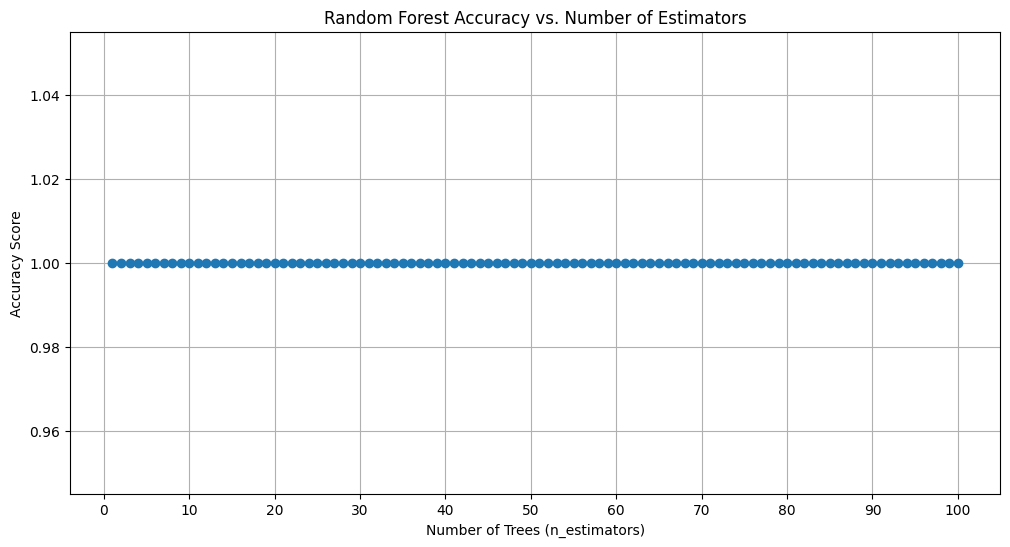

In [3]:
# Define a range of n_estimators to test
n_estimators_range = range(1, 101) # From 1 to 100 trees

# Lists to store accuracy scores
accuracy_scores = []

for n_estimators in n_estimators_range:
    # Initialize Random Forest classifier
    rf_tuned = RandomForestClassifier(n_estimators=n_estimators, random_state=42)

    # Train the model
    rf_tuned.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_tuned = rf_tuned.predict(X_test)

    # Calculate accuracy and store it
    accuracy_scores.append(accuracy_score(y_test, y_pred_tuned))

# Find the best accuracy and the corresponding number of trees
best_accuracy = max(accuracy_scores)
best_n_estimators = n_estimators_range[np.argmax(accuracy_scores)]

print(f"Best accuracy achieved: {best_accuracy:.4f}")
print(f"Number of trees (n_estimators) for best accuracy: {best_n_estimators}")

# Plotting the accuracy vs. n_estimators
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, accuracy_scores, marker='o', linestyle='-')
plt.title('Random Forest Accuracy vs. Number of Estimators')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy Score')
plt.xticks(np.arange(0, 101, 10)) # Show ticks every 10 estimators
plt.grid(True)
plt.show()